# Moment Network Patch Visualization

This notebook loads one selected Planck Q/U patch, downgrades it to `384x384`, runs one selected moment-network checkpoint, and plots the observed data, GNILC maps, posterior mean, posterior standard deviation, residuals, and polarization-amplitude diagnostics.

Set `PATCH_ID`, `MODEL_NAME`, and `CHECKPOINT_NAME` in the paths cell.


In [1]:
from pathlib import Path
import json

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120})

## Paths

Choose the patch and one moment-network model. `MODEL_NAME` is the directory name under `moment_network_training`.


In [2]:
PATCH_ID = 20
MODEL_NAME = "version_2_qu_i_splitstd_moment_fixedmean/"
CHECKPOINT_NAME = "moment_network_joint_latest.pth"

PROJECT_ROOT = Path("/Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/Moment Network")
SIGNAL_ROOT = Path("/Users/tsouros/Desktop/Projects/Planck data/BK_CMB_S4_north_patch_v4/signal")
GNILC_ROOT = Path("/Users/tsouros/Desktop/Projects/Planck data/BK_CMB_S4_north_patch_v4/GNILC")
PATCH_DIR = SIGNAL_ROOT / f"patch_{PATCH_ID}"


def resolve_one(root, pattern, label, *, recursive=False):
    matches = sorted(root.rglob(pattern) if recursive else root.glob(pattern))
    if len(matches) != 1:
        names = [str(m) for m in matches]
        raise FileNotFoundError(
            f"Expected exactly one {label} file for patch {PATCH_ID} with pattern {pattern!r}; "
            f"found {len(matches)}: {names}"
        )
    return matches[0]


Q_PATH = resolve_one(PATCH_DIR, f"patch_{PATCH_ID}_Q353_PR4*.npy", "Q353")
U_PATH = resolve_one(PATCH_DIR, f"patch_{PATCH_ID}_U353_PR4*.npy", "U353")
I_PATH = resolve_one(PATCH_DIR, f"patch_{PATCH_ID}_I857_PR4*.npy", "I857")
Q_GNILC_PATH = resolve_one(GNILC_ROOT, f"Q_GNILC_PR3_patch_{PATCH_ID}_*.npy", "Q GNILC", recursive=True)
U_GNILC_PATH = resolve_one(GNILC_ROOT, f"U_GNILC_PR3_patch_{PATCH_ID}_*.npy", "U GNILC", recursive=True)

MODEL_PATH = PROJECT_ROOT / "moment_network_training" / MODEL_NAME / "models" / CHECKPOINT_NAME
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Selected checkpoint not found: {MODEL_PATH}")

print("patch:", PATCH_ID)
print("Q:", Q_PATH)
print("U:", U_PATH)
print("I:", I_PATH)
print("Q GNILC:", Q_GNILC_PATH)
print("U GNILC:", U_GNILC_PATH)
print("model:", MODEL_PATH)


patch: 20
Q: /Users/tsouros/Desktop/Projects/Planck data/BK_CMB_S4_north_patch_v4/signal/patch_20/patch_20_Q353_PR4_no_PS_map_zero_adjust_cen_pix_lon_254.970703125_lat_54.340912303861245_v4_10_arcmin.npy
U: /Users/tsouros/Desktop/Projects/Planck data/BK_CMB_S4_north_patch_v4/signal/patch_20/patch_20_U353_PR4_no_PS_map_zero_adjust_cen_pix_lon_254.970703125_lat_54.340912303861245_v4_10_arcmin.npy
I: /Users/tsouros/Desktop/Projects/Planck data/BK_CMB_S4_north_patch_v4/signal/patch_20/patch_20_I857_PR4_no_PS_map_zero_adjust_cen_pix_lon_254.970703125_lat_54.340912303861245_v4_10_arcmin.npy
Q GNILC: /Users/tsouros/Desktop/Projects/Planck data/BK_CMB_S4_north_patch_v4/GNILC/Q_GNILC_PR3_patch_20_cen_pix_lon_254.970703125_lat_54.340912303861245_MJy_sr.npy
U GNILC: /Users/tsouros/Desktop/Projects/Planck data/BK_CMB_S4_north_patch_v4/GNILC/U_GNILC_PR3_patch_20_cen_pix_lon_254.970703125_lat_54.340912303861245_MJy_sr.npy
model: /Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/Moment Network/m

## Downgrade Utilities

This matches the moment-network preprocessing: `2x2` block average and then center crop to `384x384` if needed.

In [3]:
MAP_SIZE = 384

def downsample_by_four(image):
    image = np.asarray(image)
    if image.ndim != 2:
        raise ValueError(f"Expected a 2D map, got {image.shape}")
    h, w = image.shape
    if h % 2 or w % 2:
        raise ValueError(f"Map dimensions must be even for 2x2 averaging, got {image.shape}")
    return image.reshape(h // 2, 2, w // 2, 2).mean(axis=(1, 3))

def center_crop(image, out_hw=(MAP_SIZE, MAP_SIZE)):
    out_h, out_w = out_hw
    h, w = image.shape
    if out_h > h or out_w > w:
        raise ValueError(f"Cannot crop {image.shape} to {out_hw}")
    y0 = (h - out_h) // 2
    x0 = (w - out_w) // 2
    return image[y0:y0 + out_h, x0:x0 + out_w]

def load_and_downgrade(path, map_size=MAP_SIZE):
    raw = np.load(path).astype(np.float64)
    if raw.shape == (map_size, map_size):
        downgraded = raw
    elif raw.shape == (2 * map_size, 2 * map_size):
        downgraded = center_crop(downsample_by_four(raw), out_hw=(map_size, map_size))
    else:
        raise ValueError(
            f"Expected {path.name} to have shape {(2 * map_size, 2 * map_size)} "
            f"or {(map_size, map_size)}, got {raw.shape}"
        )
    return downgraded.astype(np.float32), raw.shape

q_map, q_raw_shape = load_and_downgrade(Q_PATH)
u_map, u_raw_shape = load_and_downgrade(U_PATH)
q_gnilc, q_gnilc_raw_shape = load_and_downgrade(Q_GNILC_PATH)
u_gnilc, u_gnilc_raw_shape = load_and_downgrade(U_GNILC_PATH)
observed_qu = np.stack([q_map, u_map], axis=0)
gnilc_qu = np.stack([q_gnilc, u_gnilc], axis=0)

print("Q raw:", q_raw_shape, "downgraded:", q_map.shape)
print("U raw:", u_raw_shape, "downgraded:", u_map.shape)
print("Q GNILC raw:", q_gnilc_raw_shape, "downgraded:", q_gnilc.shape)
print("U GNILC raw:", u_gnilc_raw_shape, "downgraded:", u_gnilc.shape)
print("observed Q/U:", observed_qu.shape)
print("GNILC Q/U:", gnilc_qu.shape)


Q raw: (768, 768) downgraded: (384, 384)
U raw: (768, 768) downgraded: (384, 384)
Q GNILC raw: (768, 768) downgraded: (384, 384)
U GNILC raw: (768, 768) downgraded: (384, 384)
observed Q/U: (2, 384, 384)
GNILC Q/U: (2, 384, 384)


## Model Definition

This is the same `LSSUNet` used by `train_network.py`.

In [4]:
class ConvGN(nn.Module):
    def __init__(self, in_ch, out_ch, groups=8):
        super().__init__()
        groups = min(groups, out_ch)
        if out_ch % groups != 0:
            groups = 1
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=True)
        self.norm = nn.GroupNorm(num_groups=groups, num_channels=out_ch, eps=1e-5, affine=True)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class LSSUNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=2):
        super().__init__()
        self.c1 = ConvGN(in_channels, 16)
        self.p1 = nn.AvgPool2d(2)
        self.c2 = ConvGN(16, 32)
        self.p2 = nn.AvgPool2d(2)
        self.c3 = ConvGN(32, 64)
        self.p3 = nn.AvgPool2d(2)
        self.c4 = ConvGN(64, 64)
        self.p4 = nn.AvgPool2d(2)
        self.c5 = ConvGN(64, 64)
        self.c6 = ConvGN(128, 64)
        self.c7 = ConvGN(128, 64)
        self.c8 = ConvGN(96, 32)
        self.c9 = ConvGN(48, 16)
        self.final = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        b1 = self.c1(x)
        b2 = self.c2(self.p1(b1))
        b3 = self.c3(self.p2(b2))
        b4 = self.c4(self.p3(b3))
        b5 = self.c5(self.p4(b4))
        u6 = F.interpolate(b5, size=b4.shape[-2:], mode="nearest")
        b6 = self.c6(torch.cat([b4, u6], dim=1))
        u7 = F.interpolate(b6, size=b3.shape[-2:], mode="nearest")
        b7 = self.c7(torch.cat([b3, u7], dim=1))
        u8 = F.interpolate(b7, size=b2.shape[-2:], mode="nearest")
        b8 = self.c8(torch.cat([b2, u8], dim=1))
        u9 = F.interpolate(b8, size=b1.shape[-2:], mode="nearest")
        b9 = self.c9(torch.cat([b1, u9], dim=1))
        return self.final(b9)

## Load Checkpoints and Run Inference


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def final_out_channels(state_dict):
    weight = state_dict.get("final.weight")
    if weight is None:
        raise KeyError("Could not find final.weight in checkpoint state dict")
    return int(weight.shape[0])

def checkpoint_stats(checkpoint):
    normalization = checkpoint["normalization"]
    return {
        "input_mean": np.asarray(normalization["input_mean"], dtype=np.float32),
        "input_std": np.asarray(normalization["input_std"], dtype=np.float32),
        "target_mean": np.asarray(normalization["target_mean"], dtype=np.float32),
        "target_std": np.asarray(normalization["target_std"], dtype=np.float32),
    }

def observed_for_stats(stats):
    n_input = int(stats["input_mean"].size)
    if n_input == 2:
        return observed_qu
    if n_input == 3:
        i_map, i_raw_shape = load_and_downgrade(I_PATH)
        print("I raw:", i_raw_shape, "downgraded:", i_map.shape)
        return np.concatenate([observed_qu, i_map[None]], axis=0)
    raise RuntimeError(f"Unsupported checkpoint input channel count: {n_input}")

def infer_checkpoint(model_path, label):
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model_format = checkpoint.get("model_format", "legacy_joint")
    stats = checkpoint_stats(checkpoint)
    n_input = int(stats["input_mean"].size)
    observed = observed_for_stats(stats)

    input_mean = stats["input_mean"].reshape(n_input, 1, 1)
    input_std = stats["input_std"].reshape(n_input, 1, 1)
    target_mean = stats["target_mean"].reshape(2, 1, 1)
    target_std = stats["target_std"].reshape(2, 1, 1)

    observed_norm = (observed - input_mean) / input_std
    tensor = torch.from_numpy(observed_norm[None].astype(np.float32)).to(device=device)

    if "std_q_model_state_dict" in checkpoint and "std_u_model_state_dict" in checkpoint:
        mean_state = checkpoint["mean_model_state_dict"]
        std_q_state = checkpoint["std_q_model_state_dict"]
        std_u_state = checkpoint["std_u_model_state_dict"]
        mean_output_channels = int(checkpoint.get("mean_model_output_channels", final_out_channels(mean_state)))

        mean_model = LSSUNet(in_channels=n_input, out_channels=mean_output_channels).to(device)
        std_q_model = LSSUNet(in_channels=n_input, out_channels=1).to(device)
        std_u_model = LSSUNet(in_channels=n_input, out_channels=1).to(device)
        mean_model.load_state_dict(mean_state)
        std_q_model.load_state_dict(std_q_state)
        std_u_model.load_state_dict(std_u_state)
        mean_model.eval()
        std_q_model.eval()
        std_u_model.eval()

        with torch.no_grad():
            mean_output_norm = mean_model(tensor).cpu().numpy()[0]
            mean_norm = mean_output_norm[:2]
            logvar_q = std_q_model(tensor).cpu().numpy()[0][:1]
            logvar_u = std_u_model(tensor).cpu().numpy()[0][:1]
            logvar_norm = np.concatenate([logvar_q, logvar_u], axis=0)
    elif "mean_model_state_dict" in checkpoint and "variance_model_state_dict" in checkpoint:
        mean_state = checkpoint["mean_model_state_dict"]
        variance_state = checkpoint["variance_model_state_dict"]
        mean_output_channels = int(checkpoint.get("mean_model_output_channels", final_out_channels(mean_state)))
        variance_output_channels = final_out_channels(variance_state)

        mean_model = LSSUNet(in_channels=n_input, out_channels=mean_output_channels).to(device)
        variance_model = LSSUNet(in_channels=n_input, out_channels=variance_output_channels).to(device)
        mean_model.load_state_dict(mean_state)
        variance_model.load_state_dict(variance_state)
        mean_model.eval()
        variance_model.eval()

        with torch.no_grad():
            mean_output_norm = mean_model(tensor).cpu().numpy()[0]
            mean_norm = mean_output_norm[:2]
            logvar_norm = variance_model(tensor).cpu().numpy()[0][:2]
    else:
        model_state = checkpoint["model_state_dict"]
        mean_output_channels = final_out_channels(model_state)
        legacy_model = LSSUNet(in_channels=n_input, out_channels=mean_output_channels).to(device)
        legacy_model.load_state_dict(model_state)
        legacy_model.eval()

        with torch.no_grad():
            mean_output_norm = legacy_model(tensor).cpu().numpy()[0]
            mean_norm = mean_output_norm[:2]
            logvar_norm = mean_output_norm[2:4]

    logvar_norm = np.clip(logvar_norm, -12.0, 12.0)
    std_norm = np.exp(0.5 * logvar_norm)
    mean = (mean_norm * target_std + target_mean).astype(np.float32)
    std = (std_norm * target_std).astype(np.float32)

    result = {
        "label": label,
        "model_path": model_path,
        "checkpoint": checkpoint,
        "model_format": model_format,
        "stats": stats,
        "observed": observed,
        "mean_output_norm": mean_output_norm,
        "mean_output_channels": mean_output_channels,
        "mean": mean,
        "std": std,
        "logvar_norm": logvar_norm,
    }
    print(f"[{label}] model_format:", model_format)
    print(f"[{label}] n_input:", n_input)
    print(f"[{label}] mean_output_channels:", mean_output_channels)
    print(f"[{label}] observed:", observed.shape, "mean:", mean.shape, "std:", std.shape)
    return result

result = infer_checkpoint(MODEL_PATH, MODEL_NAME)


device: cpu
I raw: (768, 768) downgraded: (384, 384)
[version_2_qu_i_splitstd_moment_fixedmean/] model_format: joint_qu_i_split_std_moment_mse
[version_2_qu_i_splitstd_moment_fixedmean/] n_input: 3
[version_2_qu_i_splitstd_moment_fixedmean/] mean_output_channels: 2
[version_2_qu_i_splitstd_moment_fixedmean/] observed: (3, 384, 384) mean: (2, 384, 384) std: (2, 384, 384)


## Plotting Helper


In [6]:
def robust_symmetric_limits(arrays, q=99.0):
    vals = np.concatenate([np.asarray(a).ravel() for a in arrays])
    vals = vals[np.isfinite(vals)]
    lim = np.nanpercentile(np.abs(vals), q) if vals.size else 1.0
    if not np.isfinite(lim) or lim <= 0:
        lim = np.nanmax(np.abs(vals)) if vals.size else 1.0
    if not np.isfinite(lim) or lim <= 0:
        lim = 1.0
    return -float(lim), float(lim)

def positive_limits(arrays, q=99.0):
    vals = np.concatenate([np.asarray(a).ravel() for a in arrays])
    vals = vals[np.isfinite(vals)]
    vmax = np.nanpercentile(vals, q) if vals.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = np.nanmax(vals) if vals.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    return 0.0, float(vmax)

def plot_inference(result, gnilc, *, freq=353):
    observed, mean, std = result["observed"][:2], result["mean"], result["std"]
    fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), constrained_layout=True)
    for row, label in enumerate(("Q", "U")):
        map_vmin, map_vmax = robust_symmetric_limits([observed[row], gnilc[row], mean[row]])
        std_vmin, std_vmax = positive_limits([std[row]])
        panels = [
            (f"{label}{freq} data", observed[row], "coolwarm", map_vmin, map_vmax),
            (f"{label} GNILC", gnilc[row], "coolwarm", map_vmin, map_vmax),
            (f"{label} posterior mean", mean[row], "coolwarm", map_vmin, map_vmax),
            (f"{label} posterior std", std[row], "viridis", std_vmin, std_vmax),
        ]
        for col, (title, arr, cmap, vmin, vmax) in enumerate(panels):
            im = axes[row, col].imshow(arr, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            axes[row, col].set_title(title); axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
            fig.colorbar(im, ax=axes[row, col], shrink=0.82)
    fig.suptitle(f"Patch {PATCH_ID} | {result['label']}\n{result['model_path'].name} | {result['model_format']}", fontsize=13)
    return fig

def polarization_amplitude(qu):
    qu = np.asarray(qu)
    return np.sqrt(np.square(qu[0]) + np.square(qu[1]))

def residual_comparisons(result, gnilc):
    observed = np.asarray(result["observed"][:2])
    data_minus_gnilc = (observed - np.asarray(gnilc)).astype(np.float32)
    data_minus_mean = (observed - np.asarray(result["mean"])).astype(np.float32)
    return data_minus_gnilc, data_minus_mean

def plot_residual_comparisons(result, gnilc):
    data_minus_gnilc, data_minus_mean = residual_comparisons(result, gnilc)
    vmin, vmax = robust_symmetric_limits([
        data_minus_gnilc[0], data_minus_gnilc[1],
        data_minus_mean[0], data_minus_mean[1],
    ])
    fig, axes = plt.subplots(2, 2, figsize=(9, 8), constrained_layout=True)
    rows = [
        ("data - GNILC", data_minus_gnilc),
        ("data - posterior mean", data_minus_mean),
    ]
    for row, (row_label, residual) in enumerate(rows):
        for col, stokes in enumerate(("Q", "U")):
            ax = axes[row, col]
            im = ax.imshow(residual[col], origin="lower", cmap="coolwarm", vmin=vmin, vmax=vmax)
            ax.set_title(f"{stokes}: {row_label}")
            ax.set_xticks([])
            ax.set_yticks([])
            fig.colorbar(im, ax=ax, shrink=0.82)
    fig.suptitle(f"Patch {PATCH_ID} | residual comparisons", fontsize=13)
    arrays = {
        "data_minus_gnilc": data_minus_gnilc,
        "data_minus_mean": data_minus_mean,
    }
    return fig, arrays

def plot_p_diagnostics(result, gnilc):
    p_data = polarization_amplitude(result["observed"][:2])
    p_gnilc = polarization_amplitude(gnilc)
    p_mean = polarization_amplitude(result["mean"])
    p_std = polarization_amplitude(result["std"])
    mean_vmin, mean_vmax = positive_limits([p_data, p_gnilc, p_mean])
    std_vmin, std_vmax = positive_limits([p_std])
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), constrained_layout=True)
    panels = [
        ("P data", p_data, "magma", mean_vmin, mean_vmax),
        ("P GNILC", p_gnilc, "magma", mean_vmin, mean_vmax),
        ("P posterior mean", p_mean, "magma", mean_vmin, mean_vmax),
        ("P posterior std amplitude", p_std, "viridis", std_vmin, std_vmax),
    ]
    for ax, (title, arr, cmap, vmin, vmax) in zip(axes, panels):
        im = ax.imshow(arr, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); fig.colorbar(im, ax=ax, shrink=0.82)
    fig.suptitle(f"Patch {PATCH_ID} | P = sqrt(Q^2 + U^2)", fontsize=13)
    arrays = {"p_data": p_data.astype(np.float32), "p_gnilc": p_gnilc.astype(np.float32), "p_mean": p_mean.astype(np.float32), "p_std": p_std.astype(np.float32)}
    return fig, arrays


## Selected Model Result

Observed data, downgraded GNILC map, posterior mean, and posterior standard deviation for Q and U.


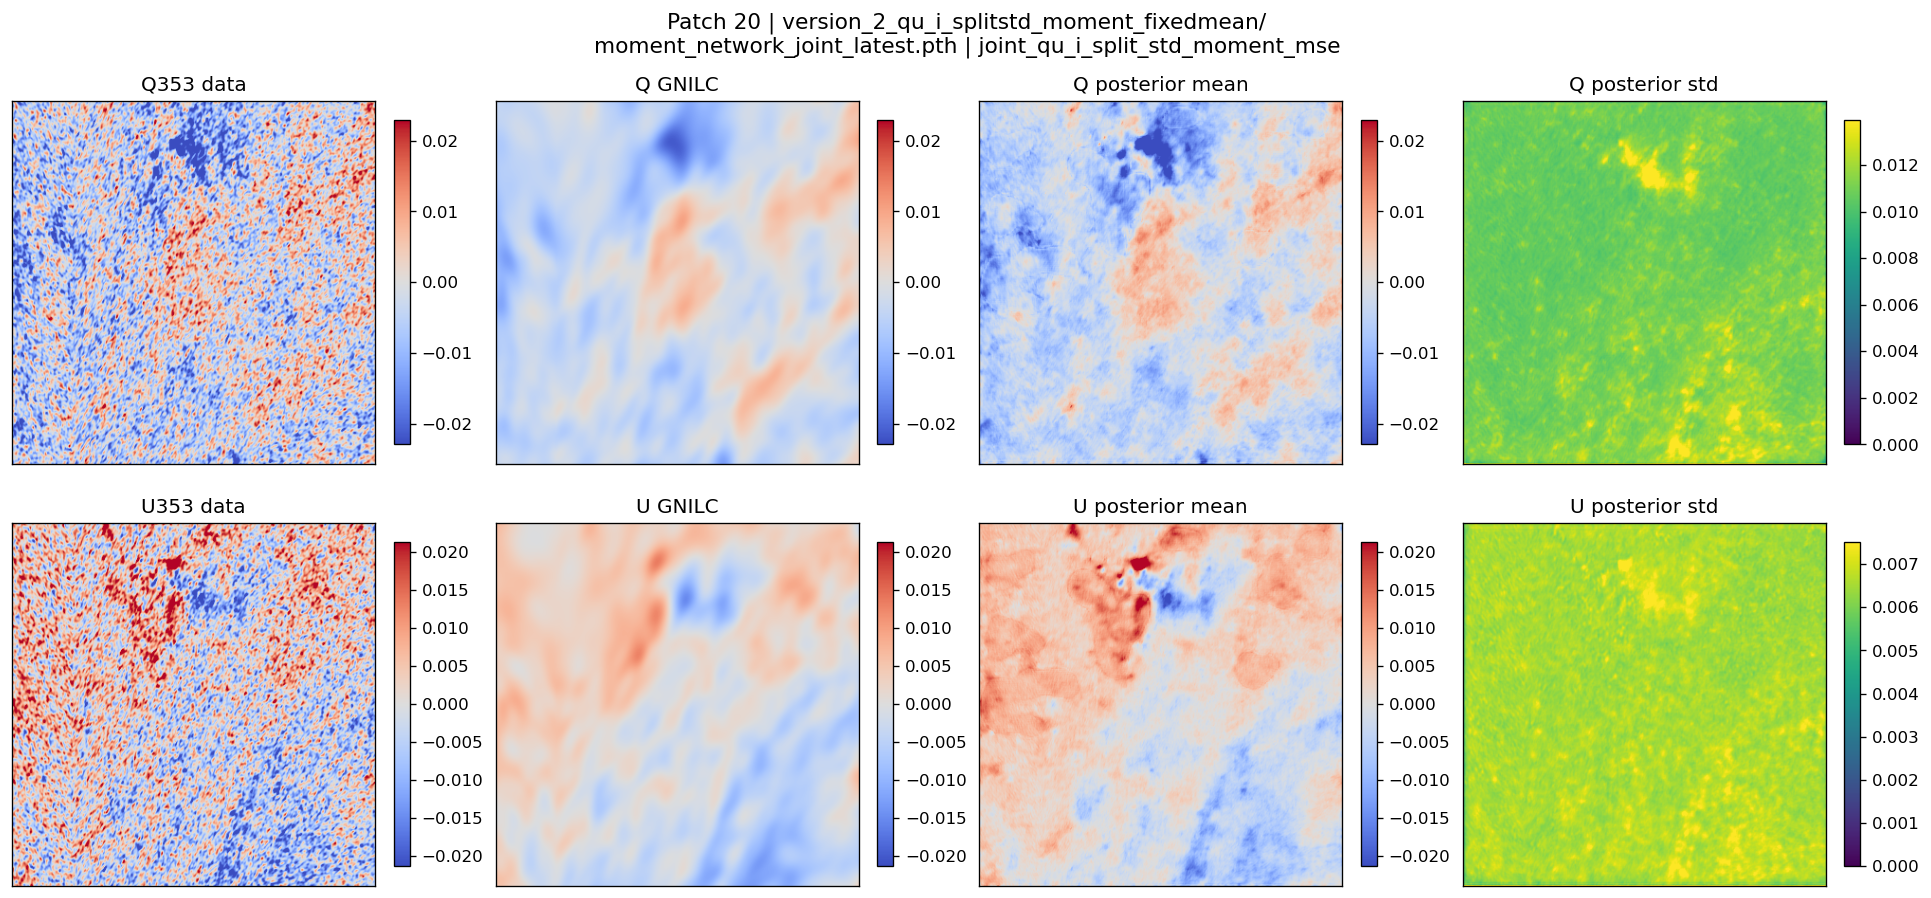

In [7]:
fig_inference = plot_inference(result, gnilc_qu)
plt.show()


## Residual Comparisons

For Q and U, compare the residuals $d-\mathrm{GNILC}$ and $d-\mu(d)$ using the same symmetric color scale.


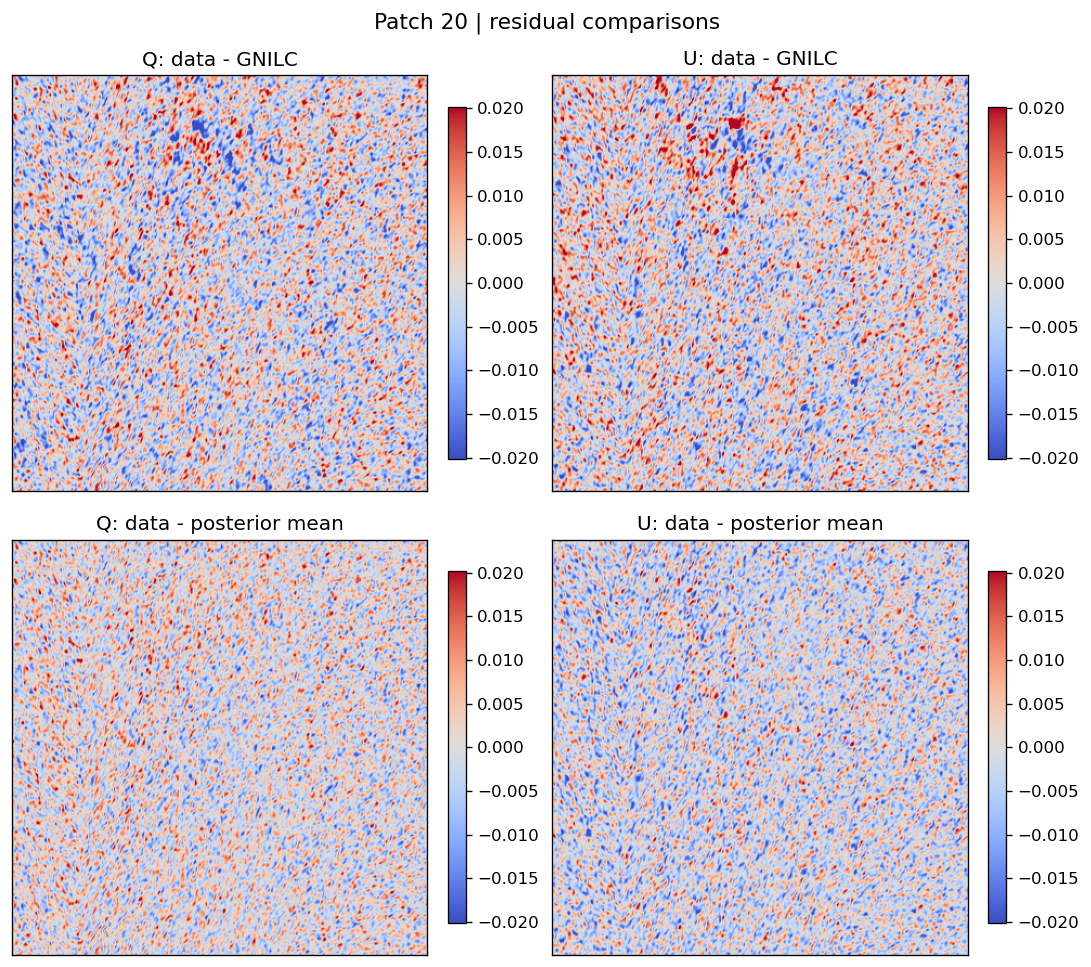

In [8]:
fig_residual_comparison, residual_arrays = plot_residual_comparisons(result, gnilc_qu)
plt.show()


## Polarization Amplitude Diagnostics

Plots $P=\sqrt{Q^2+U^2}$ for the observed data, GNILC map, posterior mean, and posterior standard-deviation amplitude.


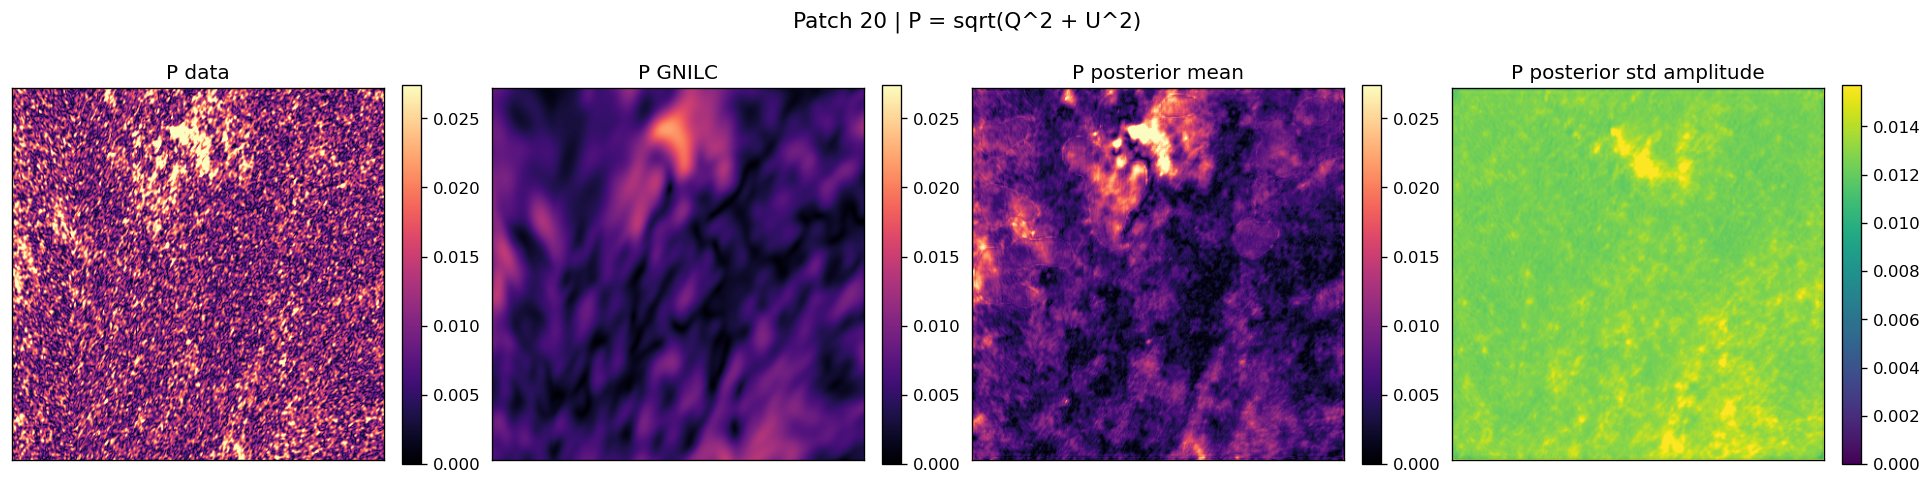

In [9]:
fig_p_diagnostics, p_arrays = plot_p_diagnostics(result, gnilc_qu)
plt.show()


## Optional: Save Figures and Arrays


In [10]:
MODEL_TAG = MODEL_NAME.replace("/", "_")
OUT_DIR = PROJECT_ROOT / "mn_plots" / f"local_patch{PATCH_ID}" / MODEL_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

inference_fig_path = OUT_DIR / f"patch{PATCH_ID}_{MODEL_TAG}_inference.png"
residual_comparison_fig_path = OUT_DIR / f"patch{PATCH_ID}_{MODEL_TAG}_data_minus_gnilc_and_mean.png"
p_diagnostics_fig_path = OUT_DIR / f"patch{PATCH_ID}_{MODEL_TAG}_p_diagnostics.png"
npz_path = OUT_DIR / f"patch{PATCH_ID}_{MODEL_TAG}_inference_arrays.npz"

fig_inference.savefig(inference_fig_path, dpi=180, bbox_inches="tight")
fig_residual_comparison.savefig(residual_comparison_fig_path, dpi=180, bbox_inches="tight")
fig_p_diagnostics.savefig(p_diagnostics_fig_path, dpi=180, bbox_inches="tight")
np.savez_compressed(
    npz_path,
    observed_qu=observed_qu,
    gnilc_qu=gnilc_qu,
    mean=result["mean"],
    std=result["std"],
    logvar_norm=result["logvar_norm"],
    mean_output_norm=result["mean_output_norm"],
    mean_output_channels=result["mean_output_channels"],
    model_path=str(result["model_path"]),
    model_format=result["model_format"],
    **residual_arrays,
    **p_arrays,
)

print("saved inference figure:", inference_fig_path)
print("saved residual-comparison figure:", residual_comparison_fig_path)
print("saved P diagnostics figure:", p_diagnostics_fig_path)
print("saved arrays:", npz_path)


saved inference figure: /Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/Moment Network/mn_plots/local_patch20/version_2_qu_i_splitstd_moment_fixedmean_/patch20_version_2_qu_i_splitstd_moment_fixedmean__inference.png
saved residual-comparison figure: /Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/Moment Network/mn_plots/local_patch20/version_2_qu_i_splitstd_moment_fixedmean_/patch20_version_2_qu_i_splitstd_moment_fixedmean__data_minus_gnilc_and_mean.png
saved P diagnostics figure: /Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/Moment Network/mn_plots/local_patch20/version_2_qu_i_splitstd_moment_fixedmean_/patch20_version_2_qu_i_splitstd_moment_fixedmean__p_diagnostics.png
saved arrays: /Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/Moment Network/mn_plots/local_patch20/version_2_qu_i_splitstd_moment_fixedmean_/patch20_version_2_qu_i_splitstd_moment_fixedmean__inference_arrays.npz
